In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
DATASET_FOLDER = "/content/drive/MyDrive/Dataset (1)"
DATASETS = [
    "DIATAquarium.v4i.yolov8",
    "Aquatic Plant.v2i.yolov8",
    "well.v8i.yolov8"]
print("Dataset folder exists:", os.path.exists(DATASET_FOLDER))
print("Datasets:")
for dataset in DATASETS:
    path = os.path.join(DATASET_FOLDER, dataset)
    print(dataset, "->", os.path.exists(path))

Mounted at /content/drive
Dataset folder exists: True
Datasets:
DIATAquarium.v4i.yolov8 -> True
Aquatic Plant.v2i.yolov8 -> True
well.v8i.yolov8 -> True


In [ ]:
from PIL import Image
import os
from collections import Counter
print("STEP 2: RESOLUTION AUDIT")
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    print()
    print("Dataset:", dataset_name)
    print()
    for split in ["train", "valid", "test"]:
        image_path = os.path.join(dataset_path, split, "images")
        if not os.path.exists(image_path):
            print(f"\n{split}: NOT PRESENT")
            continue
        resolution_counts = Counter()
        checked = 0
        for entry in os.scandir(image_path):
            if not entry.is_file():
                continue
            if not entry.name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            try:
                with Image.open(entry.path) as img:
                    resolution_counts[img.size] += 1
                checked += 1
            except:
                pass
            if checked >= 50:
                break
        print(f"\n{split}: Checked {checked} images")
        print("Resolutions:")
        for resolution, count in resolution_counts.most_common():
            print(f"  {resolution} = {count}")

STEP 2: RESOLUTION AUDIT

Dataset: DIATAquarium.v4i.yolov8


train: Checked 50 images
Resolutions:
  (1920, 1080) = 50

valid: Checked 50 images
Resolutions:
  (2048, 1536) = 50

test: NOT PRESENT

Dataset: Aquatic Plant.v2i.yolov8


train: Checked 50 images
Resolutions:
  (640, 640) = 50

valid: Checked 50 images
Resolutions:
  (640, 640) = 50

test: Checked 50 images
Resolutions:
  (640, 640) = 50

Dataset: well.v8i.yolov8


train: Checked 50 images
Resolutions:
  (640, 640) = 50

valid: Checked 50 images
Resolutions:
  (640, 640) = 50

test: Checked 50 images
Resolutions:
  (640, 640) = 50


STEP 3: VISIBILITY AND IMAGE QUALITY AUDIT

Dataset: DIATAquarium.v4i.yolov8



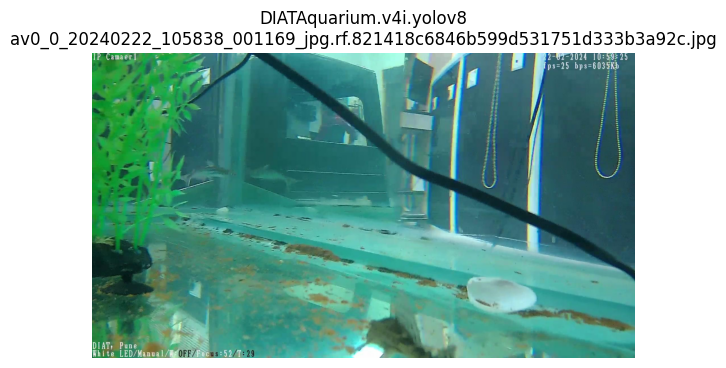

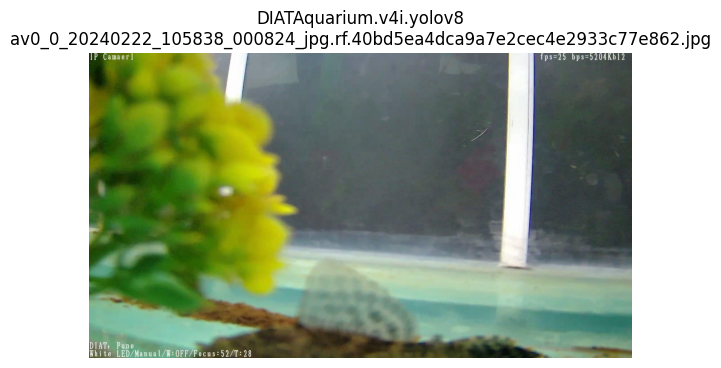

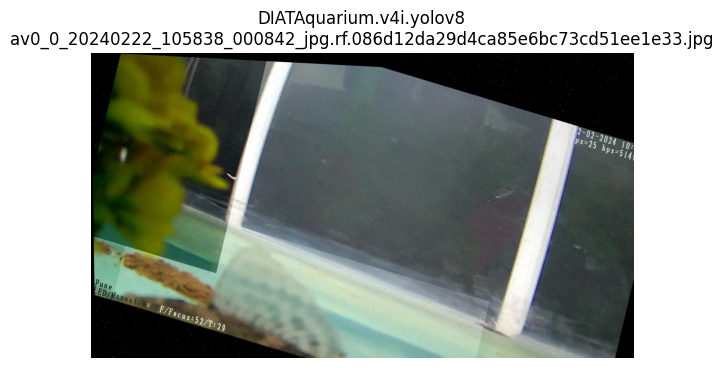


Dataset: Aquatic Plant.v2i.yolov8



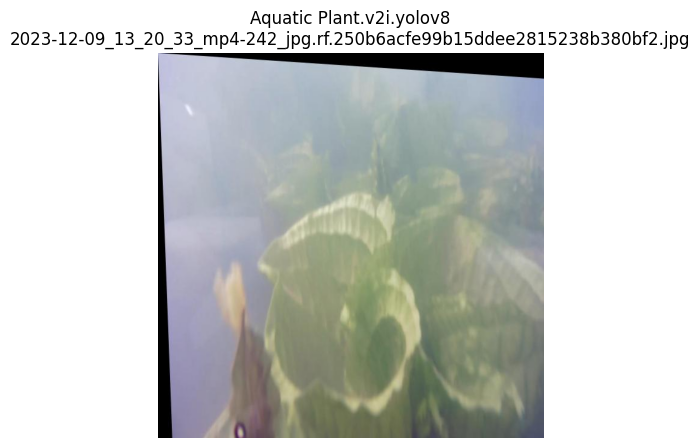

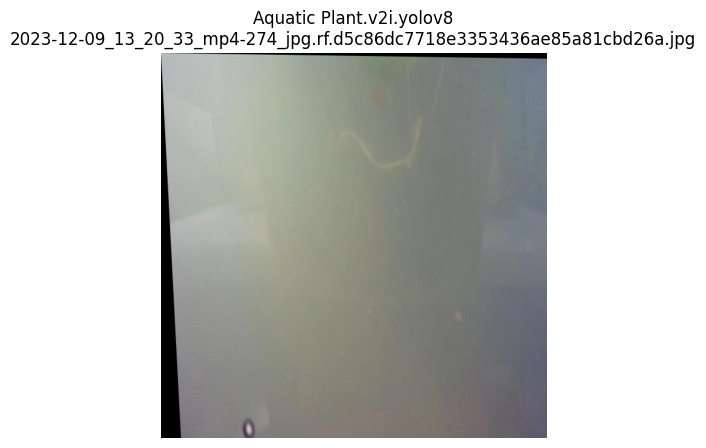

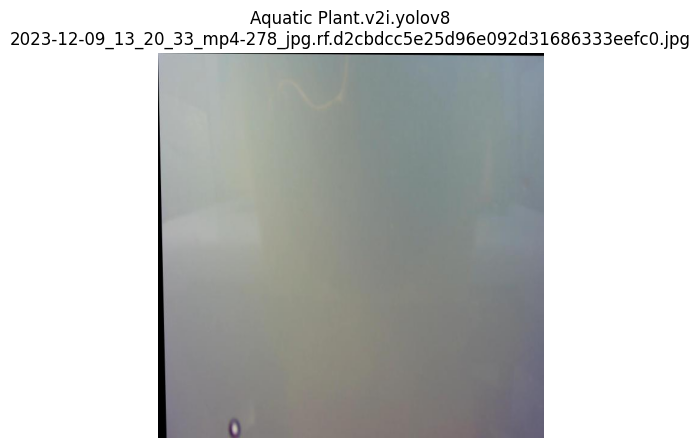


Dataset: well.v8i.yolov8



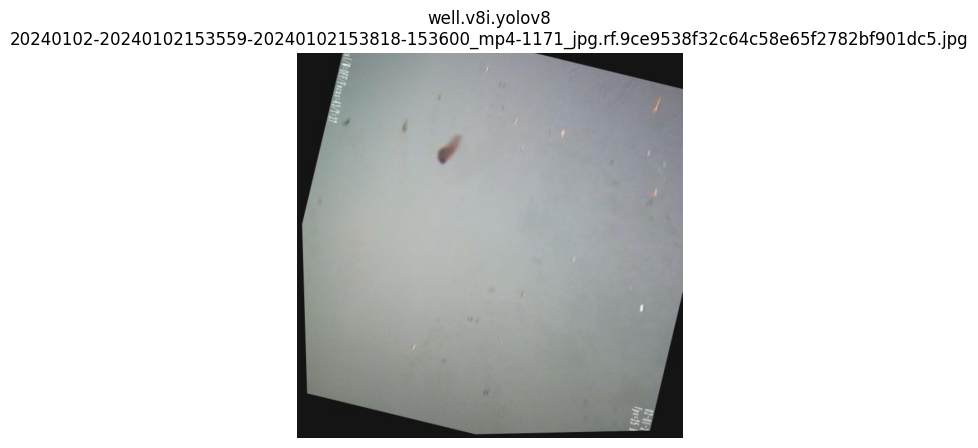

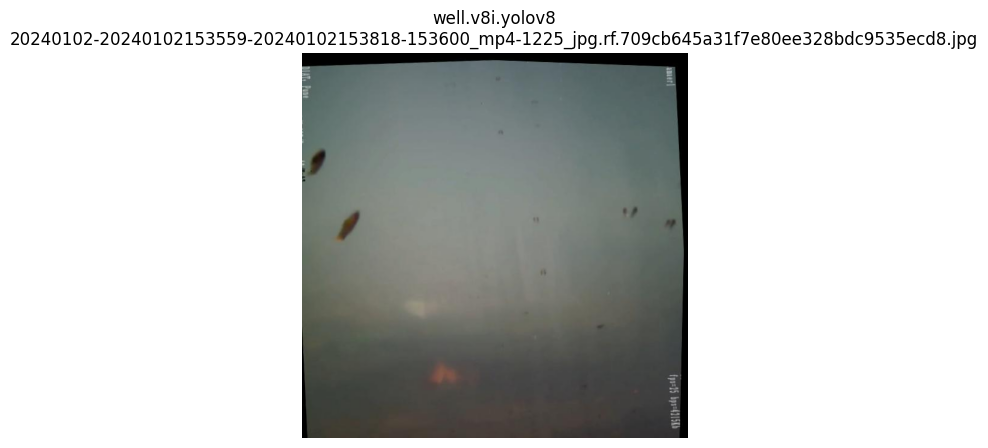

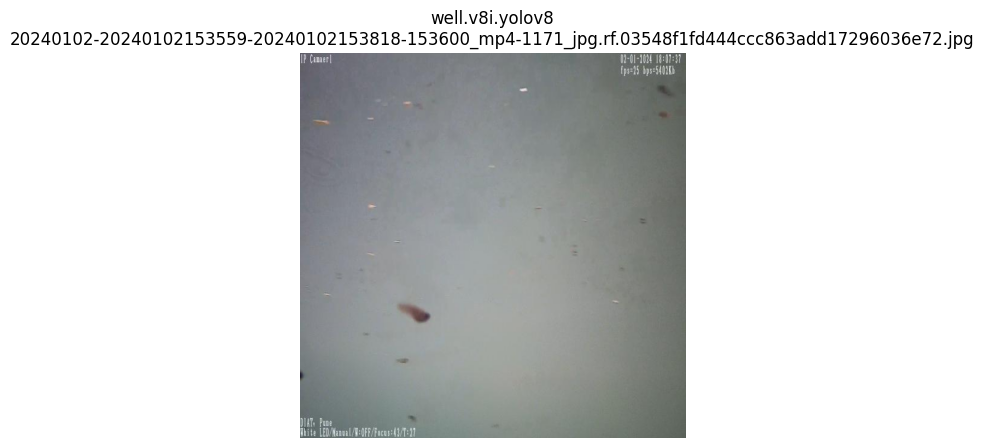

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt
print("STEP 3: VISIBILITY AND IMAGE QUALITY AUDIT")
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    image_path = os.path.join(dataset_path, "train", "images")
    print()
    print("Dataset:", dataset_name)
    print()
    if not os.path.exists(image_path):
        print("Train images not found.")
        continue
    image_files = []
    for entry in os.scandir(image_path):
        if entry.is_file() and entry.name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(entry.path)
        if len(image_files) >= 3:
            break
    for filepath in image_files:
        try:
            image = Image.open(filepath).convert("RGB")
            plt.figure(figsize=(7,5))
            plt.imshow(image)
            plt.title(f"{dataset_name}\n{os.path.basename(filepath)}")
            plt.axis("off")
            plt.show()
        except Exception as e:
            print("Could not display image:", e)

STEP 4: ANNOTATION CONSISTENCY AUDIT

Dataset: DIATAquarium.v4i.yolov8



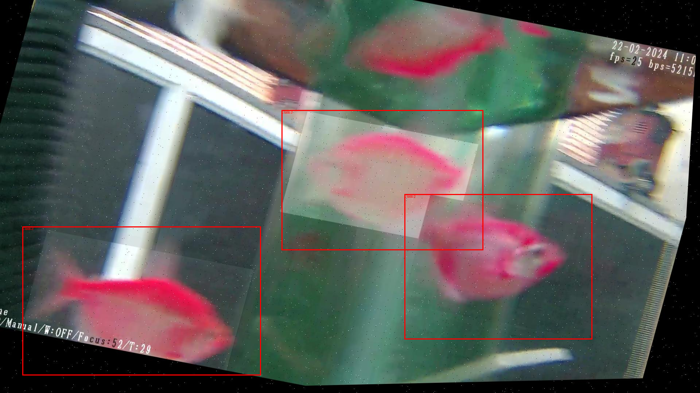

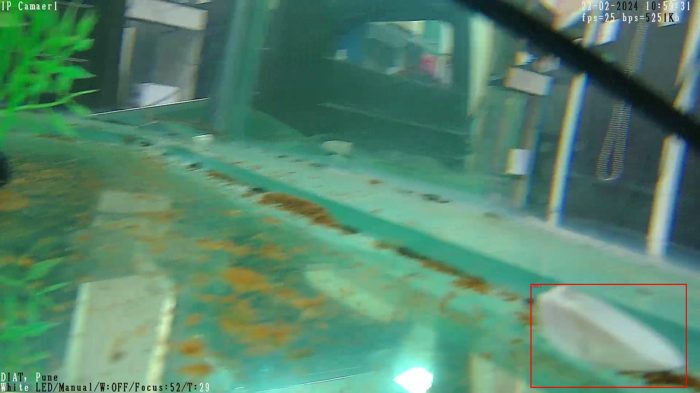

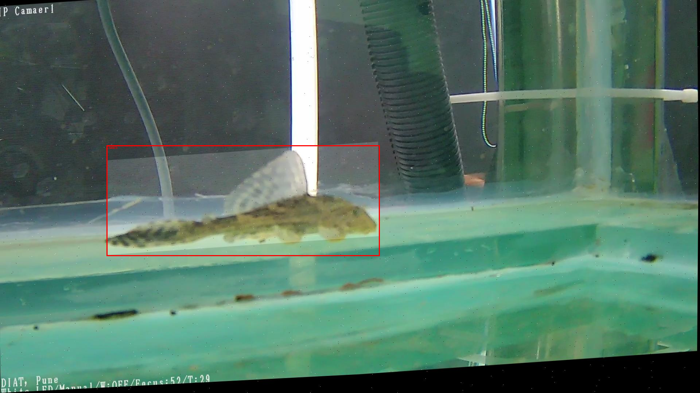


Dataset: Aquatic Plant.v2i.yolov8



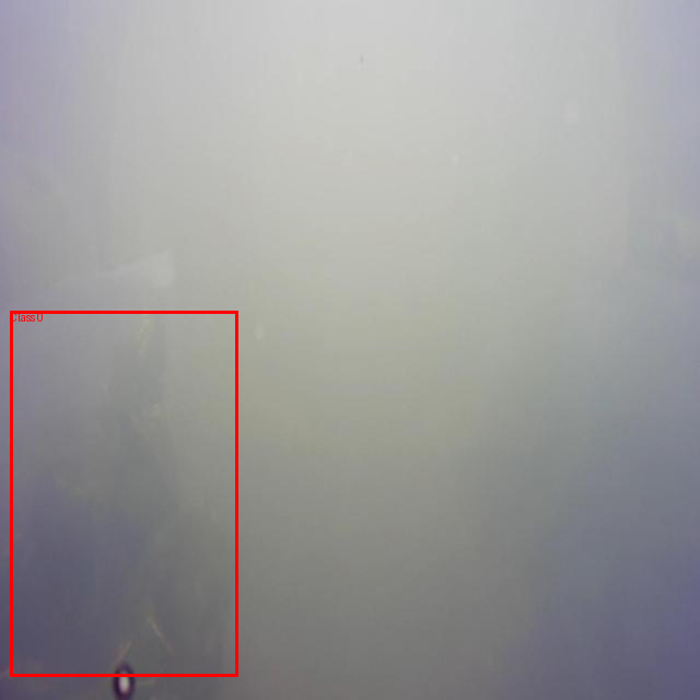

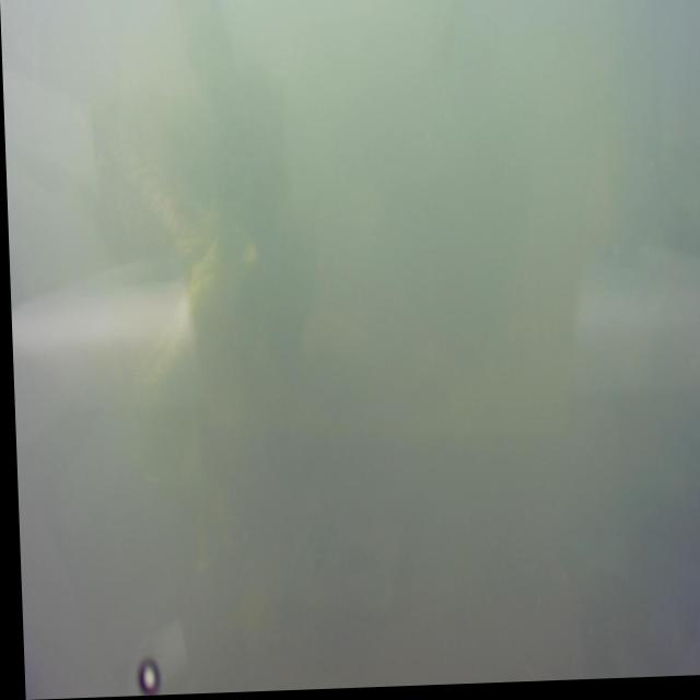

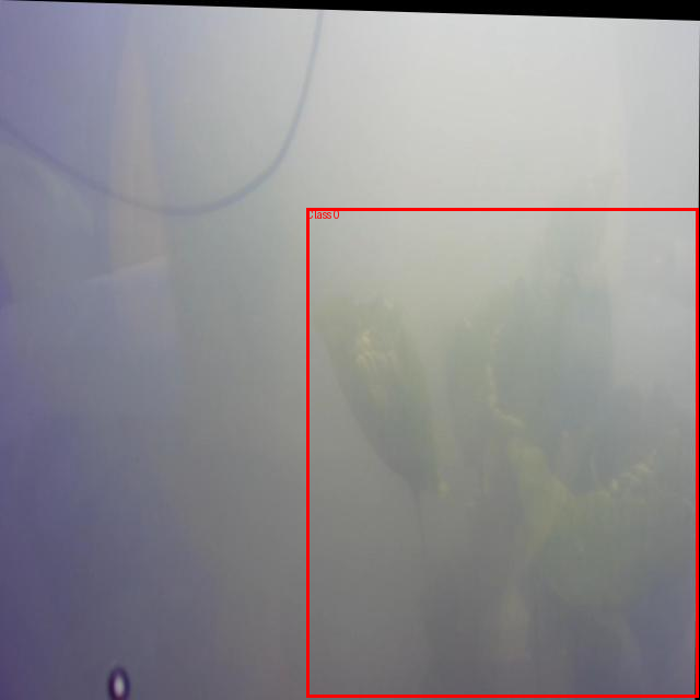


Dataset: well.v8i.yolov8



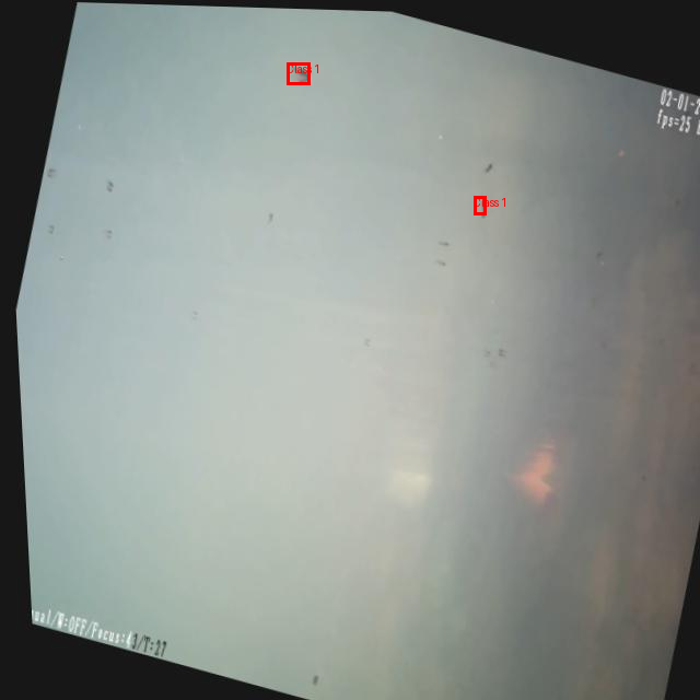

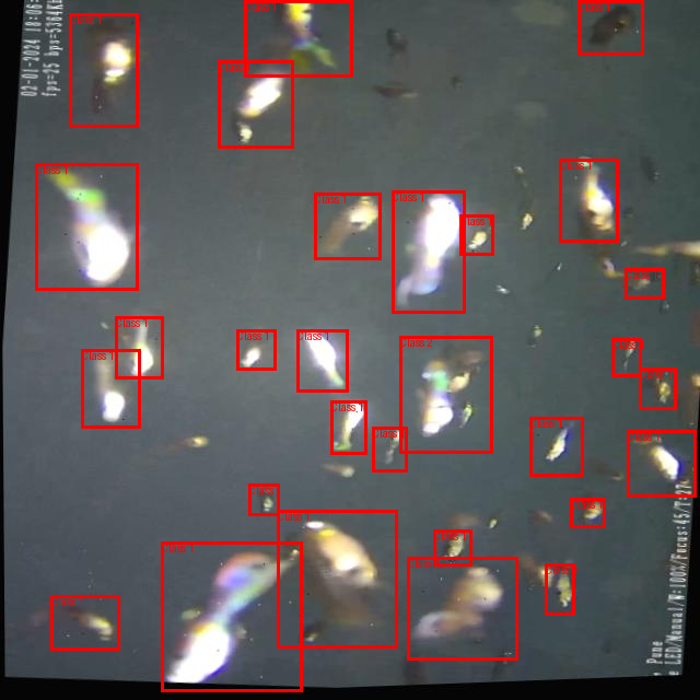

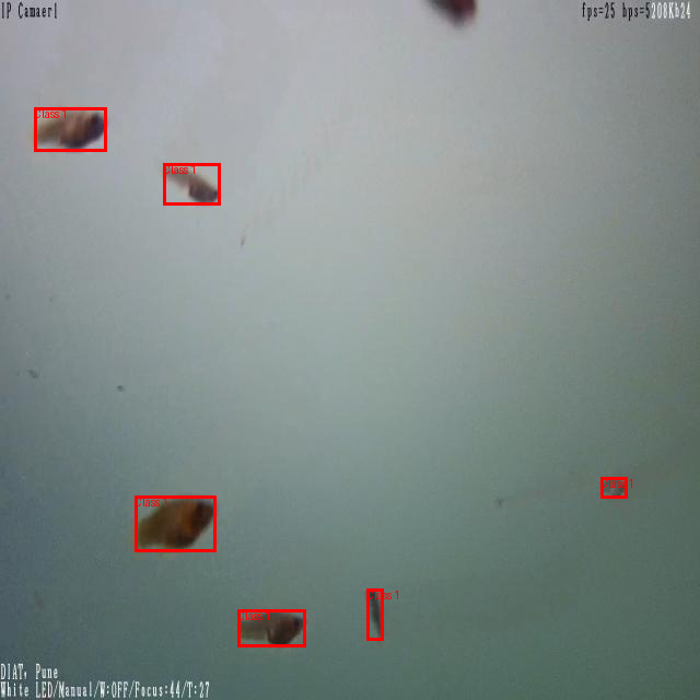

In [ ]:
from PIL import Image, ImageDraw
import os
import random
print("STEP 4: ANNOTATION CONSISTENCY AUDIT")
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    image_path = os.path.join(dataset_path, "train", "images")
    label_path = os.path.join(dataset_path, "train", "labels")
    yaml_path = os.path.join(dataset_path, "data.yaml")
    print()
    print("Dataset:", dataset_name)
    print()
    if not os.path.exists(image_path) or not os.path.exists(label_path):
        print("Images or labels folder not found.")
        continue
    image_files = [
        f for f in os.listdir(image_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    selected = random.sample(image_files, min(3, len(image_files)))
    for image_name in selected:
        image_file = os.path.join(image_path, image_name)
        label_file = os.path.join(
            label_path,
            os.path.splitext(image_name)[0] + ".txt"
        )
        image = Image.open(image_file).convert("RGB")
        draw = ImageDraw.Draw(image)
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id, x, y, w, h = map(float, parts)
                img_w, img_h = image.size
                x1 = int((x - w/2) * img_w)
                y1 = int((y - h/2) * img_h)
                x2 = int((x + w/2) * img_w)
                y2 = int((y + h/2) * img_h)
                draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
                draw.text((x1, y1), f"Class {int(class_id)}", fill="red")
        else:
            print("Missing label:", image_name)
        display(image.resize((700, int(700 * image.height / image.width))))

In [ ]:
import os
import hashlib
print("STEP 5: DUPLICATE & SPLIT INTEGRITY AUDIT")
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    print()
    print("Dataset:", dataset_name)
    print()
    split_hashes = {}
    for split in ["train", "valid", "test"]:
        image_path = os.path.join(dataset_path, split, "images")
        if not os.path.exists(image_path):
            print(split, ": NOT PRESENT")
            continue
        hashes = {}
        for entry in os.scandir(image_path):
            if entry.is_file() and entry.name.lower().endswith((".jpg", ".jpeg", ".png")):
                try:
                    with open(entry.path, "rb") as f:
                        file_hash = hashlib.md5(f.read()).hexdigest()
                    hashes[file_hash] = entry.name
                except:
                    pass
        split_hashes[split] = hashes
        print(split, "images checked:", len(hashes))
    splits = list(split_hashes.keys())
    for i in range(len(splits)):
        for j in range(i + 1, len(splits)):
            s1, s2 = splits[i], splits[j]
            common = set(split_hashes[s1]) & set(split_hashes[s2])
            print(f"Exact duplicates: {s1} vs {s2} -> {len(common)}")

STEP 5: DUPLICATE & SPLIT INTEGRITY AUDIT

Dataset: DIATAquarium.v4i.yolov8

train images checked: 8121
valid images checked: 773
test : NOT PRESENT
Exact duplicates: train vs valid -> 0

Dataset: Aquatic Plant.v2i.yolov8

train images checked: 1876
valid images checked: 179
test images checked: 89
Exact duplicates: train vs valid -> 0
Exact duplicates: train vs test -> 0
Exact duplicates: valid vs test -> 0

Dataset: well.v8i.yolov8

train images checked: 3780
valid images checked: 191
test images checked: 184
Exact duplicates: train vs valid -> 0
Exact duplicates: train vs test -> 0
Exact duplicates: valid vs test -> 0


 CLASS AND SCENE COVERAGE AUDIT

Dataset: DIATAquarium.v4i.yolov8

Class distribution:
Class 0 : 4329
Class 1 : 114
Class 2 : 1819
Class 3 : 2237
Class 4 : 325
Class 5 : 1058
Class 6 : 2429
Class 7 : 428
Class 8 : 1735
Class 9 : 171
Class 10 : 1419


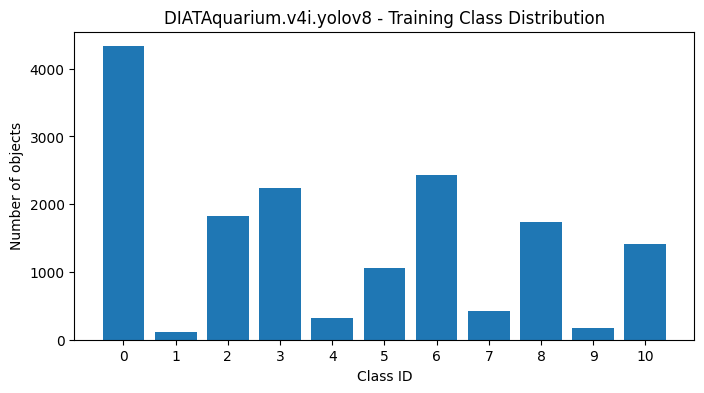


Dataset: Aquatic Plant.v2i.yolov8

Class distribution:
Class 0 : 1016


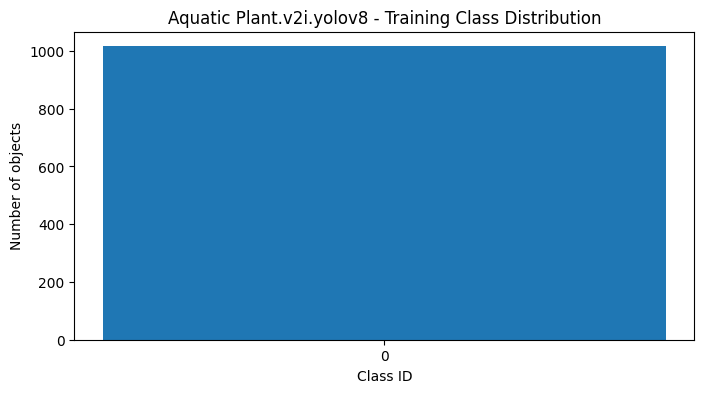


Dataset: well.v8i.yolov8

Class distribution:
Class 0 : 3
Class 1 : 45982
Class 2 : 579


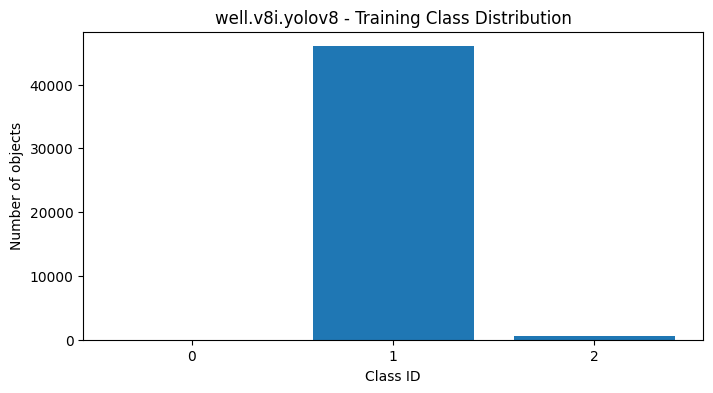

In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt
print(" CLASS AND SCENE COVERAGE AUDIT")
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    label_path = os.path.join(dataset_path, "train", "labels")
    print()
    print("Dataset:", dataset_name)
    print()
    if not os.path.exists(label_path):
        print("Train labels not found.")
        continue
    counts = Counter()
    for entry in os.scandir(label_path):
        if entry.is_file() and entry.name.endswith(".txt"):
            try:
                with open(entry.path, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            counts[int(float(parts[0]))] += 1
            except:
                pass
    print("Class distribution:")
    for class_id, count in sorted(counts.items()):
        print("Class", class_id, ":", count)
    if counts:
        plt.figure(figsize=(8,4))
        plt.bar([str(k) for k in sorted(counts)], [counts[k] for k in sorted(counts)])
        plt.title(f"{dataset_name} - Training Class Distribution")
        plt.xlabel("Class ID")
        plt.ylabel("Number of objects")
        plt.show()